# CSE 620 — Project 2: Linear Programming with the Simplex Method

This notebook walks through the full project:

**A.** Solve the lecture LP instance (`n = 4`, `m = 2`) with a custom two-phase Simplex implementation and cross-check against SciPy/HiGHS.

**B.** Scale the problem: fix `m = 2` and increase `n` from 4 to 50; for each `n`, increase `m` from 2 to 14.

**C.** Record system time, number of pivots, objective value, and solution sparsity.

**D.** Analyze the results — including infeasible / unbounded / degenerate / multiple-optima phenomena.

**Implementation notes**
- Custom solver: `src/simplex.py` (two-phase tableau Simplex with pivot counting, Dantzig rule + Bland safeguard).
- Cross-check: `scipy.optimize.linprog` (HiGHS), which does not expose pivot counts, so pivots come only from the custom solver.
- If your course's lecture LP differs from the representative one in `src/problems.py::lecture_example`, replace that function with your instance.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.simplex import simplex_solve, linprog_cross_check
from src.problems import (
    lecture_example, infeasible_example, unbounded_example,
    degenerate_example, multiple_optima_example,
    unbounded_after_removing_constraint, sparse_optimum_example,
    random_feasible_lp, random_mixed_lp,
)
from src.experiment import run_lecture_case, run_grid, run_special_cases, N_VALUES, M_VALUES

print("n values (variables):", N_VALUES)
print("m values (constraints):", M_VALUES)

n values (variables): [4, 10, 20, 30, 40, 50]
m values (constraints): [2, 6, 10, 14]


## Part A — Lecture example (n = 4, m = 2)

Maximize `z = 3x1 + 5x2 + 4x3 + 2x4` subject to
`x1 + 2x2 + x3 + x4 ≤ 12`, `2x1 + x2 + 3x3 + 2x4 ≤ 18`, `x ≥ 0`.

In [2]:
inst = lecture_example()
print(inst.description)
print("c =", inst.c)
print("A_ub =\n", inst.A_ub)
print("b_ub =", inst.b_ub)

res = simplex_solve(inst.c, A_ub=inst.A_ub, b_ub=inst.b_ub, sense=inst.sense)
print("\nCustom two-phase Simplex")
print(f"  status        : {res.status}")
print(f"  objective z*  : {res.objective:.6f}")
print(f"  x*            : {np.round(res.x, 6).tolist()}")
print(f"  pivots        : {res.pivots} (Phase I {res.phase1_pivots}, Phase II {res.phase2_pivots})")
print(f"  time          : {res.solve_time * 1e3:.3f} ms")
print(f"  degenerate    : {res.degenerate}")
print(f"  multi-optima  : {res.multiple_optima}")
print(f"  sparsity      : {res.sparsity:.1%}  (nnz = {res.n_nonzero} of n = {inst.n})")

# Feasibility + objective check
slack = inst.b_ub - inst.A_ub @ res.x
print("\nSlacks:", slack, "(all >= 0 => feasible)")
print("z = c·x =", inst.c @ res.x)

sc = linprog_cross_check(inst.c, A_ub=inst.A_ub, b_ub=inst.b_ub, sense=inst.sense)
print("\nSciPy/HiGHS:", sc["scipy_status"], "z =", sc["scipy_objective"], "nit =", sc["scipy_nit"])
print("objective match:", abs(res.objective - sc["scipy_objective"]) < 1e-8)

Lecture-style LP, n=4, m=2 (swap in your course example if different).
c = [3. 5. 4. 2.]
A_ub =
 [[1. 2. 1. 1.]
 [2. 1. 3. 2.]]
b_ub = [12. 18.]

Custom two-phase Simplex
  status        : optimal
  objective z*  : 37.200000
  x*            : [0.0, 3.6, 4.8, 0.0]
  pivots        : 2 (Phase I 0, Phase II 2)
  time          : 1.226 ms
  degenerate    : False
  multi-optima  : False
  sparsity      : 50.0%  (nnz = 2 of n = 4)

Slacks: [0. 0.] (all >= 0 => feasible)
z = c·x = 37.2



SciPy/HiGHS: optimal z = 37.2 nit = 2
objective match: True


## Part B + C — Scaling experiments

**Main grid (project requirement):** nonnegative `≤` LPs, always feasible and bounded, so every solve yields an optimum.

For each `(m, n)` we run 10 random seeds and record pivots, time (custom Simplex and SciPy), objective, sparsity, degeneracy, and alternative-optima flags.

In [3]:
df_main = run_grid(N_VALUES, M_VALUES, n_seeds=10, generator="random_feasible", use_scipy=True)
print(f"{len(df_main)} solves")
print(df_main["status"].value_counts().to_dict())
print("SciPy agreement:", df_main["objective_match"].mean())
df_main.head()

240 solves
{'optimal': 240}
SciPy agreement: 1.0


,instance,group,generator,m,n,n_ub,n_eq,seed,status,expected_status,...,degenerate,multiple_optima,n_nonzero,sparsity,message,scipy_status,scipy_objective,scipy_time,scipy_nit,objective_match
0,random_feasible_m2_n4_s0,grid,random_feasible,2,4,2,0,0,optimal,optimal,...,False,False,1,0.75,optimal solution found,optimal,2.025588,0.000997,3,True
1,random_feasible_m2_n4_s1,grid,random_feasible,2,4,2,0,1,optimal,optimal,...,False,False,2,0.50,optimal solution found,optimal,1.619105,0.000656,2,True
2,random_feasible_m2_n4_s2,grid,random_feasible,2,4,2,0,2,optimal,optimal,...,False,False,2,0.50,optimal solution found,optimal,1.496628,0.000587,2,True
3,random_feasible_m2_n4_s3,grid,random_feasible,2,4,2,0,3,optimal,optimal,...,False,False,1,0.75,optimal solution found,optimal,8.434428,0.000617,2,True
4,random_feasible_m2_n4_s4,grid,random_feasible,2,4,2,0,4,optimal,optimal,...,False,False,1,0.75,optimal solution found,optimal,2.494078,0.000592,2,True


In [4]:
# Summary table: mean pivots / time / cost / sparsity per (m, n)
ok = df_main[df_main["status"] == "optimal"]
summary = (
    ok.groupby(["m", "n"])
    .agg(
        pivots_mean=("pivots", "mean"),
        pivots_std=("pivots", "std"),
        time_ms=("simplex_time", lambda s: s.mean() * 1e3),
        scipy_ms=("scipy_time", lambda s: s.mean() * 1e3),
        objective=("objective", "mean"),
        sparsity=("sparsity", "mean"),
    )
    .round(3)
)
summary

pivots_mean  pivots_std  time_ms  scipy_ms  objective  sparsity
m  n                                                                  
2  4           1.9       0.738    0.203     0.744      2.456     0.625
   10          2.5       0.707    0.183     0.686     10.071     0.810
   20          3.4       0.699    0.165     0.575     21.004     0.910
   30          3.2       1.033    0.162     0.589     47.576     0.937
   40          4.2       1.229    0.203     0.630     49.440     0.950
   50          4.0       0.667    0.192     0.659     84.868     0.960
6  4           2.6       0.699    0.182     0.561      1.307     0.400
   10          5.3       1.494    0.253     0.622      3.970     0.610
   20          6.1       2.726    0.332     0.706      8.993     0.790
   30          6.6       2.503    0.315     0.695     12.934     0.853
   40          6.6       2.271    0.357     0.754     20.229     0.898
   50          8.0       2.357    0.329     0.677     24.415     0.898
10 4           3.5       1.080    0.286     0.711      1.151     0.300
   10          5.1       1.449    0.325     0.729      3.473     0.580
   20          8.6       2.503    0.473     0.837      7.502     0.710
   30          9.4       1.897    0.463     0.717     10.609     0.813
   40         10.8       2.741    0.541     0.769     16.261     0.840
   50         11.9       4.508    0.667     1.323     20.246     0.876
14 4           2.9       0.738    0.275     0.675      1.035     0.375
   10          6.1       2.331    0.418     0.725      3.454     0.550
   20         10.7       2.359    0.638     0.899      6.858     0.660
   30         11.5       2.550    0.696     0.786     11.203     0.757
   40         14.4       3.273    0.794     0.906     14.271     0.790
   50         13.0       4.000    0.800     1.031     19.159     0.836

### Plots — pivots, runtime, cost, and sparsity vs problem size

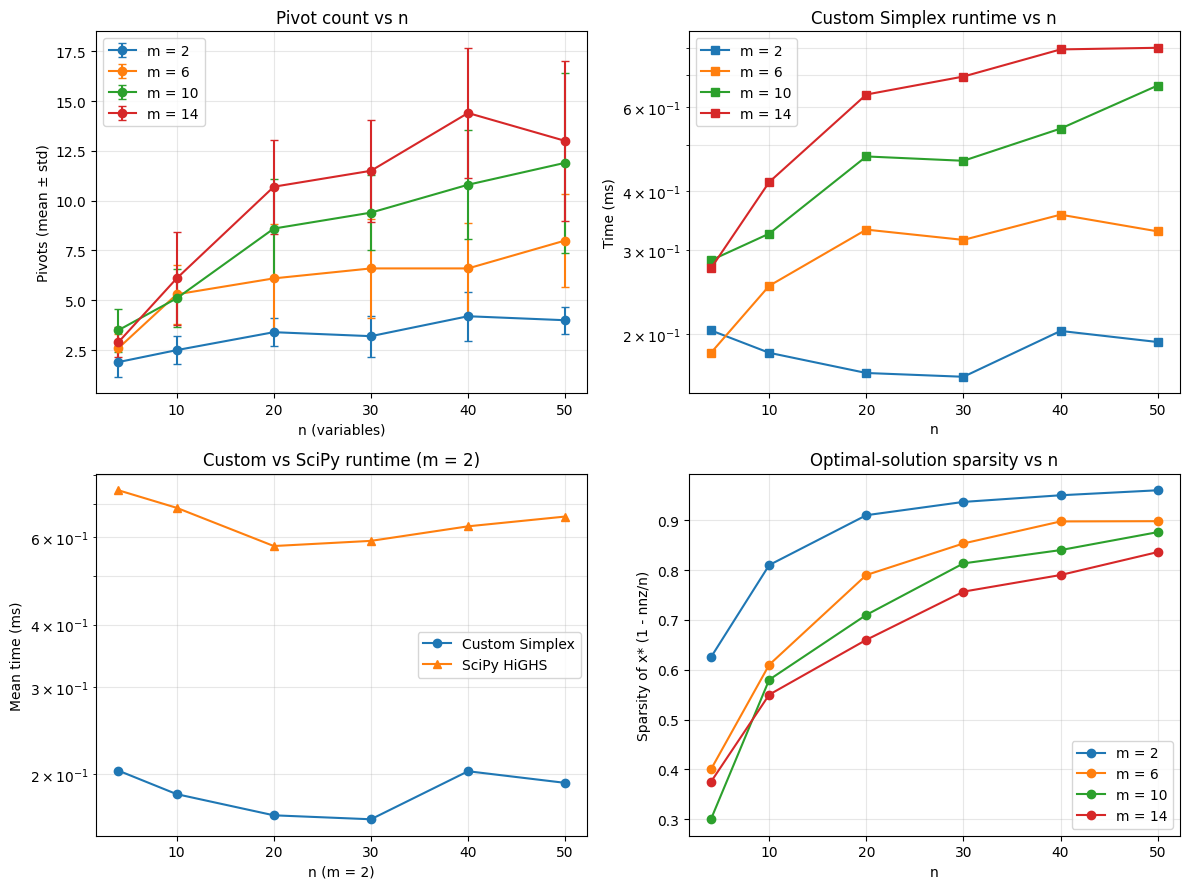

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

ax = axes[0, 0]
for m, sub in ok.groupby("m"):
    g = sub.groupby("n")["pivots"]
    ax.errorbar(g.mean().index, g.mean().values, yerr=g.std().fillna(0).values,
                marker="o", capsize=3, label=f"m = {m}")
ax.set_xlabel("n (variables)"); ax.set_ylabel("Pivots (mean ± std)")
ax.set_title("Pivot count vs n"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for m, sub in ok.groupby("m"):
    g = sub.groupby("n")["simplex_time"]
    ax.plot(g.mean().index, g.mean().values * 1e3, marker="s", label=f"m = {m}")
ax.set_xlabel("n"); ax.set_ylabel("Time (ms)"); ax.set_yscale("log")
ax.set_title("Custom Simplex runtime vs n"); ax.legend(); ax.grid(True, alpha=0.3, which="both")

ax = axes[1, 0]
sub = ok[ok["m"] == 2]
g = sub.groupby("n")
ax.plot(g["simplex_time"].mean().index, g["simplex_time"].mean().values * 1e3,
        marker="o", label="Custom Simplex")
ax.plot(g["scipy_time"].mean().index, g["scipy_time"].mean().values * 1e3,
        marker="^", label="SciPy HiGHS")
ax.set_xlabel("n (m = 2)"); ax.set_ylabel("Mean time (ms)"); ax.set_yscale("log")
ax.set_title("Custom vs SciPy runtime (m = 2)"); ax.legend(); ax.grid(True, alpha=0.3, which="both")

ax = axes[1, 1]
for m, sub in ok.groupby("m"):
    g = sub.groupby("n")["sparsity"]
    ax.plot(g.mean().index, g.mean().values, marker="o", label=f"m = {m}")
ax.set_xlabel("n"); ax.set_ylabel("Sparsity of x* (1 - nnz/n)")
ax.set_title("Optimal-solution sparsity vs n"); ax.legend(); ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### Pivots vs number of constraints `m` (one panel per `n`)

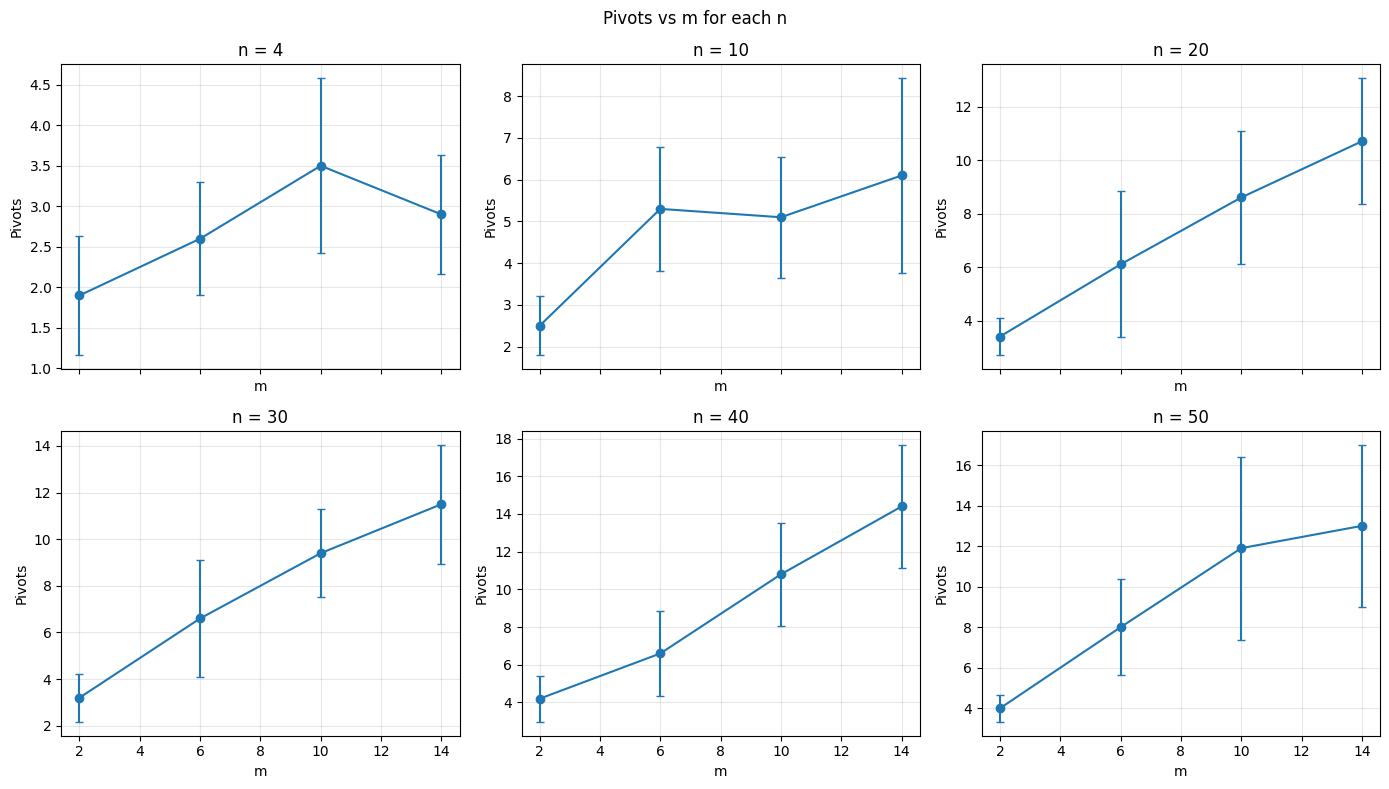

In [6]:
ns = sorted(ok["n"].unique())
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
for ax, n in zip(axes.ravel(), ns):
    sub = ok[ok["n"] == n]
    g = sub.groupby("m")["pivots"]
    ax.errorbar(g.mean().index, g.mean().values, yerr=g.std().fillna(0).values,
                marker="o", capsize=3)
    ax.set_title(f"n = {n}"); ax.set_xlabel("m"); ax.set_ylabel("Pivots")
    ax.grid(True, alpha=0.3)
fig.suptitle("Pivots vs m for each n")
fig.tight_layout()
plt.show()

## Part D-1 — Phenomena: infeasible, unbounded, degenerate, multiple optima, sparsity

Special cases that exhibit each behavior expected by the project requirements.

In [7]:
cases = [
    lecture_example(),
    infeasible_example(),
    unbounded_example(),
    degenerate_example(),
    multiple_optima_example(),
    *unbounded_after_removing_constraint(),
    sparse_optimum_example(m=4, n=20, seed=7),
    sparse_optimum_example(m=6, n=50, seed=11),
]

rows = []
for inst in cases:
    r = simplex_solve(inst.c, A_ub=inst.A_ub, b_ub=inst.b_ub, sense=inst.sense)
    sc = linprog_cross_check(inst.c, A_ub=inst.A_ub, b_ub=inst.b_ub, sense=inst.sense)
    rows.append({
        "instance": inst.name,
        "expected": inst.expected_status,
        "simplex": r.status,
        "scipy": sc["scipy_status"],
        "objective": r.objective,
        "pivots": r.pivots,
        "phase1": r.phase1_pivots,
        "phase2": r.phase2_pivots,
        "degenerate": r.degenerate,
        "multiple_optima": r.multiple_optima,
        "sparsity": round(r.sparsity, 3),
        "description": inst.description,
    })
df_cases = pd.DataFrame(rows)
df_cases

,instance,expected,simplex,scipy,objective,pivots,phase1,phase2,degenerate,multiple_optima,sparsity,description
0,lecture_example_n4_m2,optimal,optimal,optimal,37.200000,2,0,2,False,False,0.50,"Lecture-style LP, n=4, m=2 (swap in your cours..."
1,infeasible_parallel_constraints,infeasible,infeasible,infeasible,NaN,1,1,0,False,False,0.00,Disjoint parallel constraints -> empty feasibl...
2,unbounded_ray_d11,unbounded,unbounded,unbounded,NaN,1,0,1,False,False,0.00,"Recession direction d=(1,1) keeps c'd = 1 > 0 ..."
3,degenerate_vertex_3active,optimal,optimal,optimal,18.000000,2,0,2,True,False,0.50,"Optimal vertex (0,2) has 3 active constraints ..."
4,multiple_optima_face,optimal,optimal,optimal,4.000000,1,0,1,True,True,0.50,Optimal face x1+x2=4 -> infinitely many optima.
5,bounded_base_with_constraint,optimal,optimal,optimal,4.000000,1,0,1,False,True,0.50,Bounded LP: x1+x2 <= 4 caps the objective at z...
6,unbounded_after_removing_constraint,unbounded,unbounded,unbounded,NaN,0,0,0,False,False,0.00,Same LP with x1+x2<=4 removed -> only x2<=3 re...
7,sparse_optimum_m4_n20_s7,optimal,optimal,optimal,1.043406,1,0,1,False,False,0.95,Budget packing LP; optimal BFS has at most m n...
8,sparse_optimum_m6_n50_s11,optimal,optimal,optimal,1.293538,1,0,1,False,False,0.98,Budget packing LP; optimal BFS has at most m n...


**What each case shows**

| Case | Phenomenon | Why |
|------|------------|-----|
| `infeasible_parallel_constraints` | Infeasible | `x1+x2 ≤ 4` and `x1+x2 ≥ 6` are disjoint parallel half-spaces. Phase I ends with a positive artificial sum. |
| `unbounded_ray_d11` | Unbounded | Recession direction `d = (1,1)` satisfies `A d ≤ 0` with `c·d = 1 > 0`. |
| `unbounded_after_removing_constraint` | Unbounded after removing a constraint | Deleting `x1+x2 ≤ 4` opens the improving ray `(t, 3)`, `t → ∞`. |
| `degenerate_vertex_3active` | Degeneracy | Three constraints are active at the 2-variable optimum `(0,2)`, so a basic variable equals 0. |
| `multiple_optima_face` | Alternative optima | The objective `x1+x2` is parallel to the active face `x1+x2 = 4`. |
| `sparse_optimum_*` | Sparsity | At a basic feasible solution at most `m` original variables are nonzero; with `n = 50`, `m = 6`, sparsity ≈ 98%. |

## Part D-2 — Mixed-constraint grids (feasibility / boundedness stress tests)

Signed coefficients with a mix of `≤` and `≥` rows. *Well-posed* mode makes a reference point strictly feasible; *stress* mode draws random rhs signs so many instances are infeasible or unbounded.

In [8]:
df_wp = run_grid(N_VALUES, M_VALUES, n_seeds=5, generator="random_mixed", use_scipy=True, mixed_mode="wellposed")
df_st = run_grid(N_VALUES, M_VALUES, n_seeds=5, generator="random_mixed", use_scipy=True, mixed_mode="stress")

print("well-posed:", df_wp["status"].value_counts().to_dict())
print("stress    :", df_st["status"].value_counts().to_dict())
print("cross-check agreement well-posed:", df_wp["objective_match"].mean())
print("cross-check agreement stress    :", df_st["objective_match"].mean())

well-posed: {'unbounded': 91, 'optimal': 29}
stress    : {'unbounded': 95, 'infeasible': 20, 'optimal': 5}
cross-check agreement well-posed: 1.0
cross-check agreement stress    : 1.0


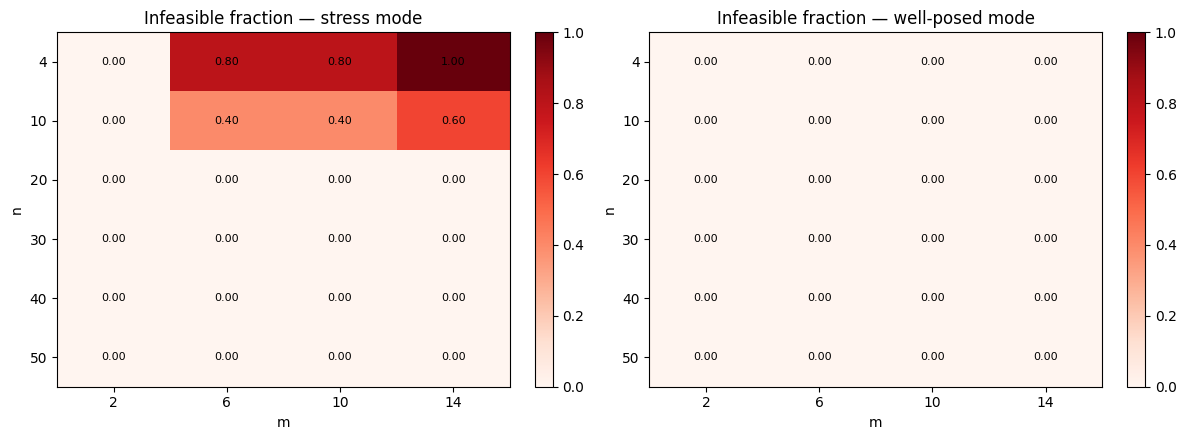

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, df, title in zip(axes, [df_st, df_wp], ["stress mode", "well-posed mode"]):
    grid = (df.assign(bad=df["status"] == "infeasible").groupby(["n", "m"])["bad"].mean().unstack("m"))
    im = ax.imshow(grid.values, cmap="Reds", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(grid.columns)), grid.columns)
    ax.set_yticks(range(len(grid.index)), grid.index)
    ax.set_xlabel("m"); ax.set_ylabel("n")
    ax.set_title(f"Infeasible fraction — {title}")
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            ax.text(j, i, f"{grid.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

## Part D-3 — Headline observations for the report

1. **Pivots grow with `m` and `n`.** On the main grid, mean pivots at `m = 2` rise from ~2 (`n = 4`) to ~4 (`n = 50`); at `n = 50` they rise from ~4 (`m = 2`) to ~13 (`m = 14`). More variables add candidate directions; more constraints create more vertices and longer pivot paths.
2. **Runtime tracks pivot count.** Each dense tableau pivot costs `O(m·n)`, so time grows roughly linearly in pivots and superlinearly in `m·n`. The custom tableau Simplex is competitive with (and often faster than) SciPy's HiGHS at these sizes because HiGHS carries substantial per-call overhead.
3. **Sparsity is structural.** A basic feasible solution has at most `m` nonzero variables among the `n` decision variables, so at fixed `m` the optimal vertex becomes sparser as `n` grows (e.g., 62% → 96% at `m = 2`). In applications (production mix, portfolio corners, network flows) this means only a few activities/assets/routes are active at optimality.
4. **Some problems have no solution / no finite optimum.** Infeasibility appears when `≥` rows demand more than `≤` rows allow (Phase I residual artificial sum > 0). Unboundedness appears when a nonbasic variable has positive reduced cost but no positive column entry — e.g., after removing a bounding constraint.
5. **Degeneracy and alternative optima are possible but nongeneric.** Hand-crafted cases trigger them; random continuous coefficients hit them with probability zero, which is why `degenerate_frac` and `multi_opt_frac` are ~0 on the main grid.
6. **Agreement with SciPy/HiGHS is exact** on every optimal instance in the main grid, validating the custom implementation.

## Saving results (optional)

Re-run the scripts from the repo root to regenerate all CSVs and plots:

```bash
.venv/bin/python scripts/run_lecture_example.py
.venv/bin/python scripts/run_grid_experiment.py
.venv/bin/python analysis/analyze_results.py
```

Outputs land in `results/` (CSVs), `results/tables/` (summaries), `results/plots/` (figures), and `results/ANALYSIS.md` (report-ready tables + discussion prompts).